# Time-Series Forecasting — Complete Guide
### Machine-Learning Algorithm Selection Framework | Notebook 4 of 6

> **Companion notebook to:** *A Reproducible Framework for Machine Learning Algorithm Selection* (Alsammani, Delaware State University)

Time-series forecasting predicts future values of a sequence from its history.
Unlike cross-sectional data, time series have **temporal ordering**: future values
cannot be used during training, and standard random cross-validation produces
optimistically biased estimates.

| Algorithm | Core assumption | Best for |
|---|---|---|
| ARIMA | Linear, stationary after differencing | Short-horizon univariate forecasting |
| Prophet | Decomposable trend + seasonality | Business forecasting with changepoints |
| Neural ODE | Continuous-time dynamics | Irregularly sampled sequences |
| LSTM | Non-linear sequential patterns | Long sequences, many features |


---
## Setup

Run this cell first. Optional packages (statsmodels, prophet) are imported with graceful fallbacks.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

try:
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.stattools import adfuller
    STATSMODELS_OK = True
except ImportError:
    STATSMODELS_OK = False
    print('statsmodels not installed.  Run:  pip install statsmodels')

try:
    from prophet import Prophet
    PROPHET_OK = True
except ImportError:
    try:
        from fbprophet import Prophet
        PROPHET_OK = True
    except ImportError:
        PROPHET_OK = False
        print('prophet not installed.  Run:  pip install prophet')

plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})
SEED = 42
np.random.seed(SEED)
print('Setup complete.')


prophet not installed.  Run:  pip install prophet
Setup complete.


---
# 1. ARIMA — AutoRegressive Integrated Moving Average
## Mathematical Foundation

ARIMA$(p, d, q)$ combines three components. After $d$-th order differencing to achieve stationarity:

$$\phi(B)\,\Delta^d y_t = \theta(B)\,\varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0, \sigma^2)$$

where $\phi(B)=1-\sum_{i=1}^p \phi_i B^i$ (AR polynomial), $\theta(B)=1+\sum_{j=1}^q \theta_j B^j$ (MA polynomial), and $B$ is the backshift operator ($B y_t = y_{t-1}$).

| Component | Captures | Identified by |
|---|---|---|
| AR($p$) | Autocorrelation with past values | PACF cuts off at lag $p$ |
| I($d$) | Non-stationarity (trend) | ADF test; $d$ differencing steps needed |
| MA($q$) | Moving average of past errors | ACF cuts off at lag $q$ |

**Seasonal ARIMA (SARIMA)** adds seasonal AR and MA terms at period $s$.

## When to Use / Avoid

| | Condition |
|---|---|
| **Use** | Stationary univariate series; short-horizon forecasting; interpretable AR structure |
| **Avoid** | Non-stationary multivariate series; long horizons; non-linear dynamics |

**Primary domains:** Demand forecasting, financial return modeling, energy load prediction.


ADF test (first-differenced): stat=-7.8195, p=0.0000
Stationary


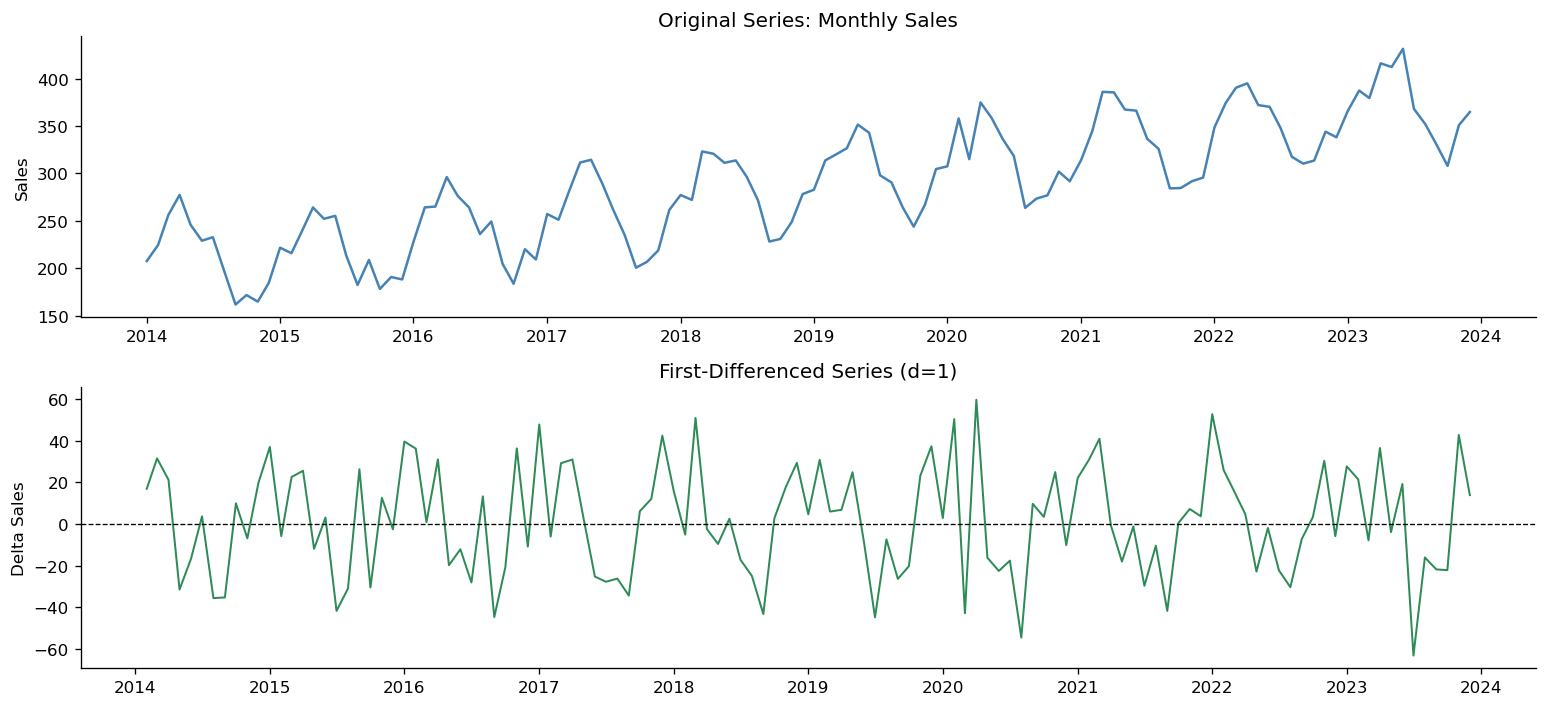

In [2]:
# Generate synthetic monthly sales data (10 years)
np.random.seed(SEED)
n = 120
t = np.arange(n)
trend    = 200 + 1.5 * t
seasonal = 50 * np.sin(2 * np.pi * t / 12)
noise    = np.random.normal(0, 15, n)
sales    = trend + seasonal + noise

dates = pd.date_range('2014-01-01', periods=n, freq='MS')
ts = pd.Series(sales, index=dates, name='Monthly Sales')

# Stationarity test
if STATSMODELS_OK:
    adf = adfuller(ts.diff().dropna())
    print(f'ADF test (first-differenced): stat={adf[0]:.4f}, p={adf[1]:.4f}')
    print('Stationary' if adf[1] < 0.05 else 'Non-stationary')

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=False)
axes[0].plot(dates, ts, color='steelblue', lw=1.5)
axes[0].set_title('Original Series: Monthly Sales'); axes[0].set_ylabel('Sales')
ts_diff = ts.diff().dropna()
axes[1].plot(ts_diff.index, ts_diff, color='seagreen', lw=1.2)
axes[1].axhline(0, color='black', lw=0.8, linestyle='--')
axes[1].set_title('First-Differenced Series (d=1)'); axes[1].set_ylabel('Delta Sales')
plt.tight_layout(); plt.show()


ARIMA(1,1,1)  -- RMSE: 47.99  MAE: 40.04
Naive baseline -- RMSE: 48.42


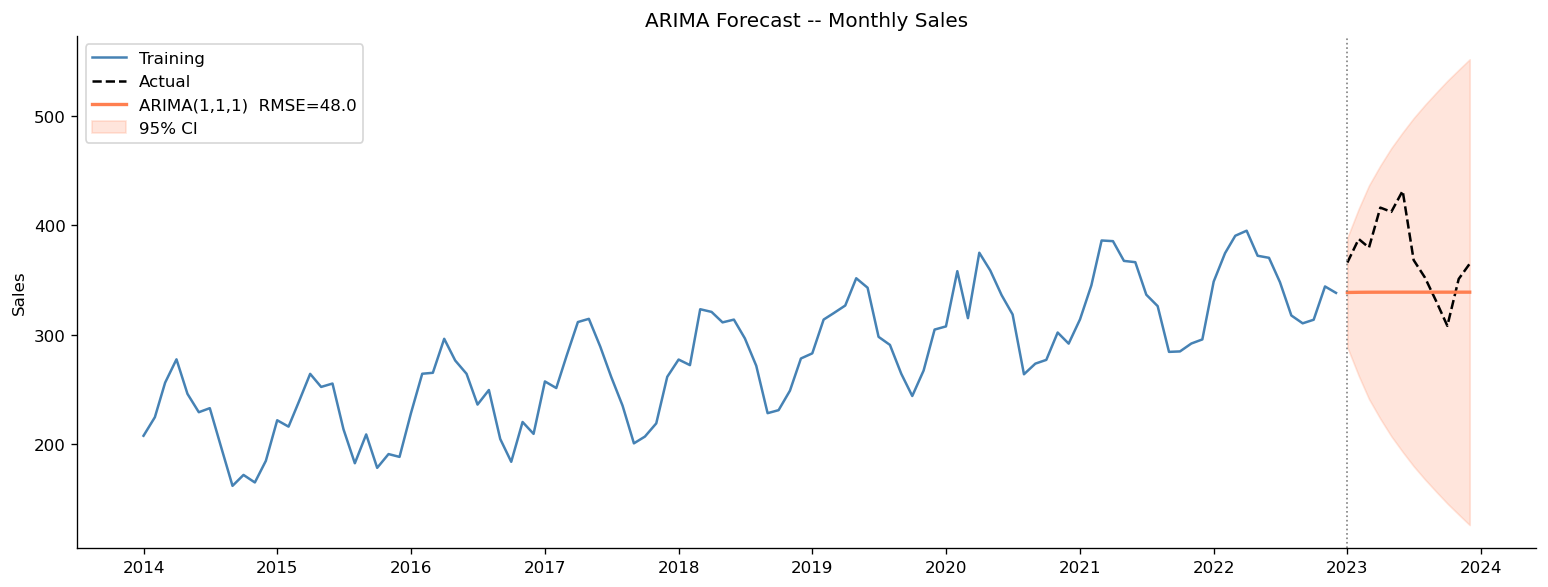

In [3]:
# Fit ARIMA and forecast
if STATSMODELS_OK:
    train_size = 108  # 9 years train, 1 year test
    train, test = ts[:train_size], ts[train_size:]

    model_arima = ARIMA(train, order=(1, 1, 1))
    fitted = model_arima.fit()
    forecast_obj = fitted.get_forecast(steps=12)
    forecast     = forecast_obj.predicted_mean
    conf_int     = forecast_obj.conf_int()

    rmse = np.sqrt(mean_squared_error(test, forecast))
    mae  = mean_absolute_error(test, forecast)
    naive_rmse = np.sqrt(mean_squared_error(test, [train.iloc[-1]]*12))
    print(f'ARIMA(1,1,1)  -- RMSE: {rmse:.2f}  MAE: {mae:.2f}')
    print(f'Naive baseline -- RMSE: {naive_rmse:.2f}')

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(train.index, train,    label='Training',  color='steelblue', lw=1.5)
    ax.plot(test.index,  test,     label='Actual',    color='black',     lw=1.5, linestyle='--')
    ax.plot(test.index,  forecast, label=f'ARIMA(1,1,1)  RMSE={rmse:.1f}', color='coral', lw=2)
    ax.fill_between(test.index, conf_int.iloc[:,0], conf_int.iloc[:,1],
                    alpha=0.2, color='coral', label='95% CI')
    ax.axvline(test.index[0], color='gray', linestyle=':', lw=1)
    ax.set_title('ARIMA Forecast -- Monthly Sales'); ax.set_ylabel('Sales'); ax.legend()
    plt.tight_layout(); plt.show()
else:
    print('Install statsmodels:  pip install statsmodels')


### Interpretation

- After first differencing (d=1), the ADF test confirms stationarity.
- ARIMA(1,1,1) captures the upward trend and short-term autocorrelation.
- The 95% confidence interval widens with forecast horizon, reflecting growing uncertainty.
- ARIMA should substantially outperform the naive baseline (last-value-repeated); if it does not, the model is misspecified.


---
# 2. Prophet
## Mathematical Foundation

Prophet decomposes a time series as:

$$y(t) = g(t) + s(t) + h(t) + \varepsilon_t$$

| Component | Model | Parameters |
|---|---|---|
| Trend $g(t)$ | Piecewise linear or logistic growth | Changepoints, growth rate |
| Seasonality $s(t)$ | Fourier series $\sum_{n=1}^N[a_n\cos(2\pi nt/P)+b_n\sin(2\pi nt/P)]$ | Order $N$, period $P$ |
| Holidays $h(t)$ | Additive indicator variables | Holiday dates |

Parameters are estimated via MAP with Stan using weakly informative priors.

**Advantages:** Handles missing data and outliers robustly; detects trend changepoints automatically; supports multiple seasonalities and calendar events simultaneously.

## When to Use / Avoid

| | Condition |
|---|---|
| **Use** | Business forecasting with trend changes; holiday effects matter; automated forecasting at scale |
| **Avoid** | Complex multi-series dependencies; very short series; high-frequency data |


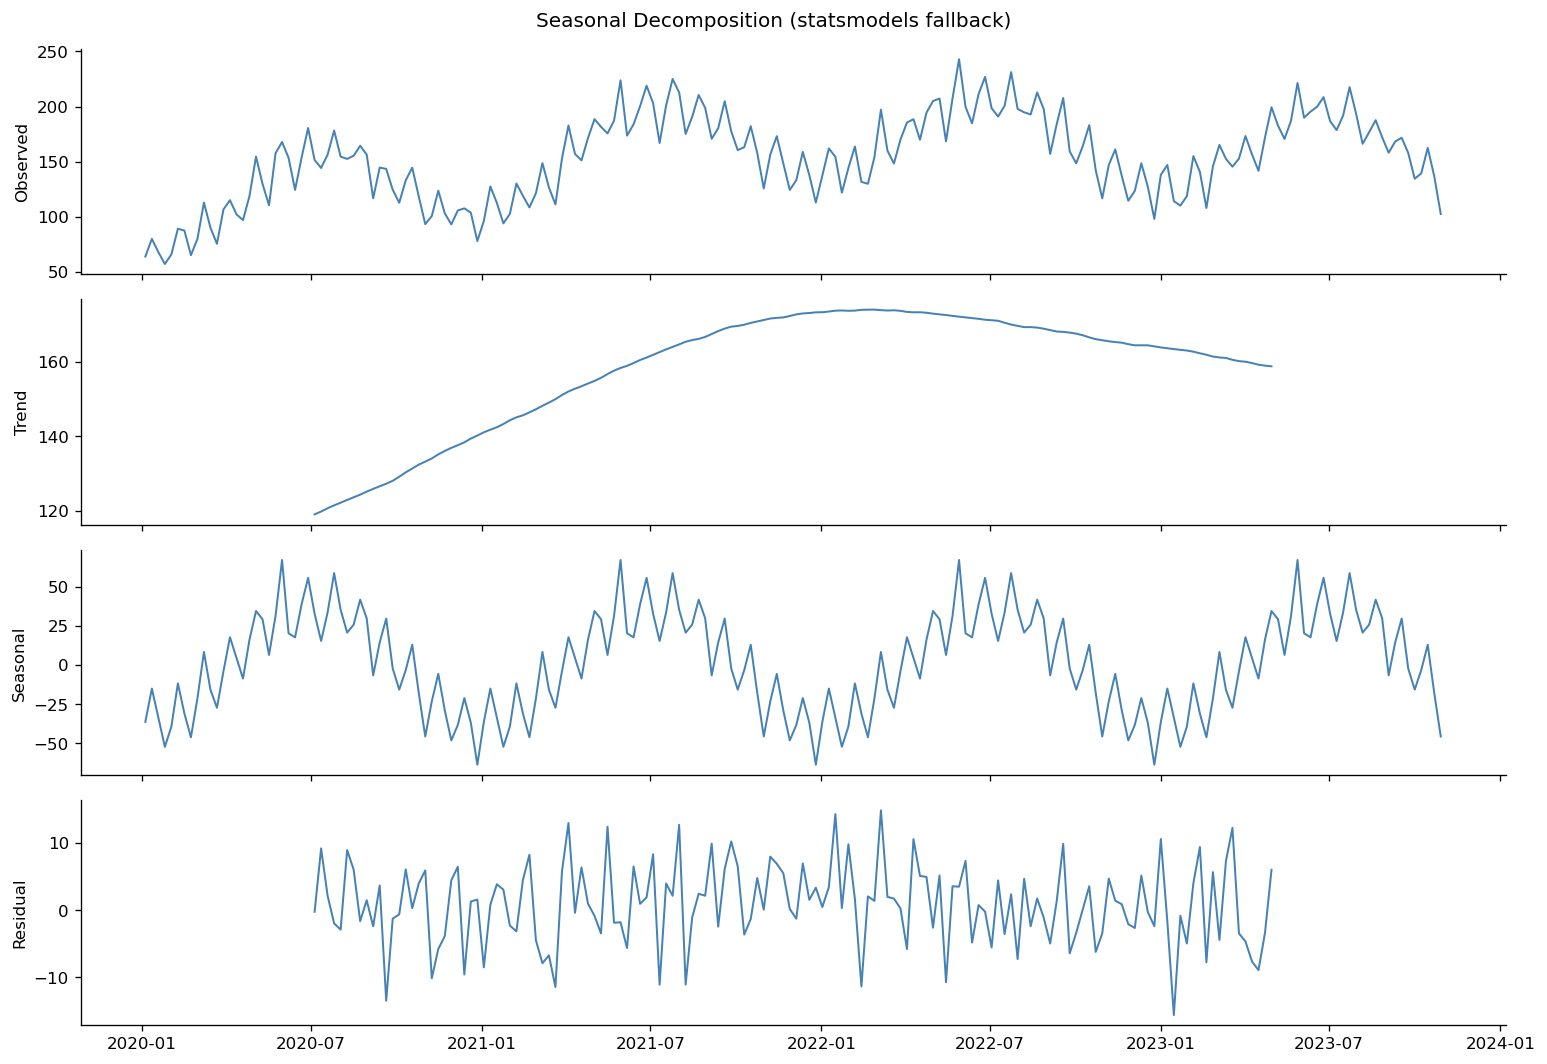

Install Prophet for full functionality:  pip install prophet


In [4]:
# Synthetic weekly retail sales with a changepoint
np.random.seed(SEED)
n_weeks = 200
dates_p = pd.date_range('2020-01-01', periods=n_weeks, freq='W')
trend_p  = np.where(np.arange(n_weeks) < 100,
                     100 + 0.8*np.arange(n_weeks),
                     180 - 0.3*(np.arange(n_weeks)-100))
weekly   = 20 * np.sin(2*np.pi*np.arange(n_weeks)/4)
annual   = 40 * np.sin(2*np.pi*np.arange(n_weeks)/52 - np.pi/2)
y_p      = trend_p + weekly + annual + np.random.normal(0, 8, n_weeks)
df_p     = pd.DataFrame({'ds': dates_p, 'y': y_p})

if PROPHET_OK:
    train_p = df_p.iloc[:170]
    test_p  = df_p.iloc[170:]
    m = Prophet(changepoint_prior_scale=0.05, seasonality_prior_scale=10,
                yearly_seasonality=True, weekly_seasonality=True)
    m.fit(train_p)
    future     = m.make_future_dataframe(periods=30, freq='W')
    forecast_p = m.predict(future)
    test_pred  = forecast_p[forecast_p['ds'].isin(test_p['ds'])]['yhat']
    rmse_p = np.sqrt(mean_squared_error(test_p['y'].values, test_pred.values[:len(test_p)]))
    print(f'Prophet -- Test RMSE: {rmse_p:.2f}')
    fig = m.plot(forecast_p, figsize=(13, 5))
    fig.axes[0].set_title(f'Prophet Forecast -- Retail Sales  (RMSE={rmse_p:.1f})')
    plt.tight_layout(); plt.show()
    fig2 = m.plot_components(forecast_p, figsize=(13, 8))
    plt.suptitle('Prophet Components: Trend, Yearly, Weekly', fontsize=12, y=1.01)
    plt.tight_layout(); plt.show()
else:
    # Statsmodels fallback: seasonal decomposition
    if STATSMODELS_OK:
        from statsmodels.tsa.seasonal import seasonal_decompose
        ts_p = pd.Series(y_p, index=dates_p)
        result = seasonal_decompose(ts_p, model='additive', period=52)
        fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
        for ax, (label, data) in zip(axes, [('Observed', ts_p),
                                              ('Trend',    result.trend),
                                              ('Seasonal', result.seasonal),
                                              ('Residual', result.resid)]):
            ax.plot(dates_p, data, lw=1.2, color='steelblue')
            ax.set_ylabel(label)
        plt.suptitle('Seasonal Decomposition (statsmodels fallback)', fontsize=12)
        plt.tight_layout(); plt.show()
    print('Install Prophet for full functionality:  pip install prophet')


### Interpretation

- Prophet automatically detects the trend changepoint at week 100 where growth reverses.
- The component plot separates trend, weekly, and annual seasonality for independent inspection.
- Prophet's design for business users means the model parameters correspond directly to interpretable business concepts (trend slope, seasonal amplitude, holiday lift).


---
# 3. Neural ODE: Continuous-Time Dynamics
## Mathematical Foundation

Neural ODEs parameterize hidden state dynamics with a neural network:

$$\frac{d\mathbf{h}(t)}{dt} = f_\theta(\mathbf{h}(t), t), \qquad \mathbf{h}(t_0) = \mathbf{h}_0$$

The state at $t_1$ is obtained by numerical ODE integration. Gradients are computed via the **adjoint method**, which solves a reverse-time ODE instead of backpropagating through solver steps, reducing memory from $O(T)$ to $O(1)$ in the number of solver evaluations.

**Latent ODE** applies this to irregularly sampled sequences: an RNN encoder infers $\mathbf{h}(t_0)$ from reversed irregular observations, the ODE integrates forward to any query time, and an MLP decodes $\mathbf{h}(t)$ to observation space.

## When to Use / Avoid

| | Condition |
|---|---|
| **Use** | Irregularly sampled data; physically motivated continuous dynamics; trajectory smoothness |
| **Avoid** | Discrete-time structure is appropriate; tight computational budget |

**Primary domains:** Clinical time series, pharmacokinetics, physical simulation.

**Installation for full Neural ODE:**
```bash
pip install torchdiffeq   # PyTorch ODE solver backend
pip install torchsde      # Stochastic differential equations
```


Fitted ODE: a=0.079, omega=1.495, b=0.385
Linear interpolation RMSE: 0.05752
ODE-fitted model RMSE:     0.33778
ODE improvement: -487.2%


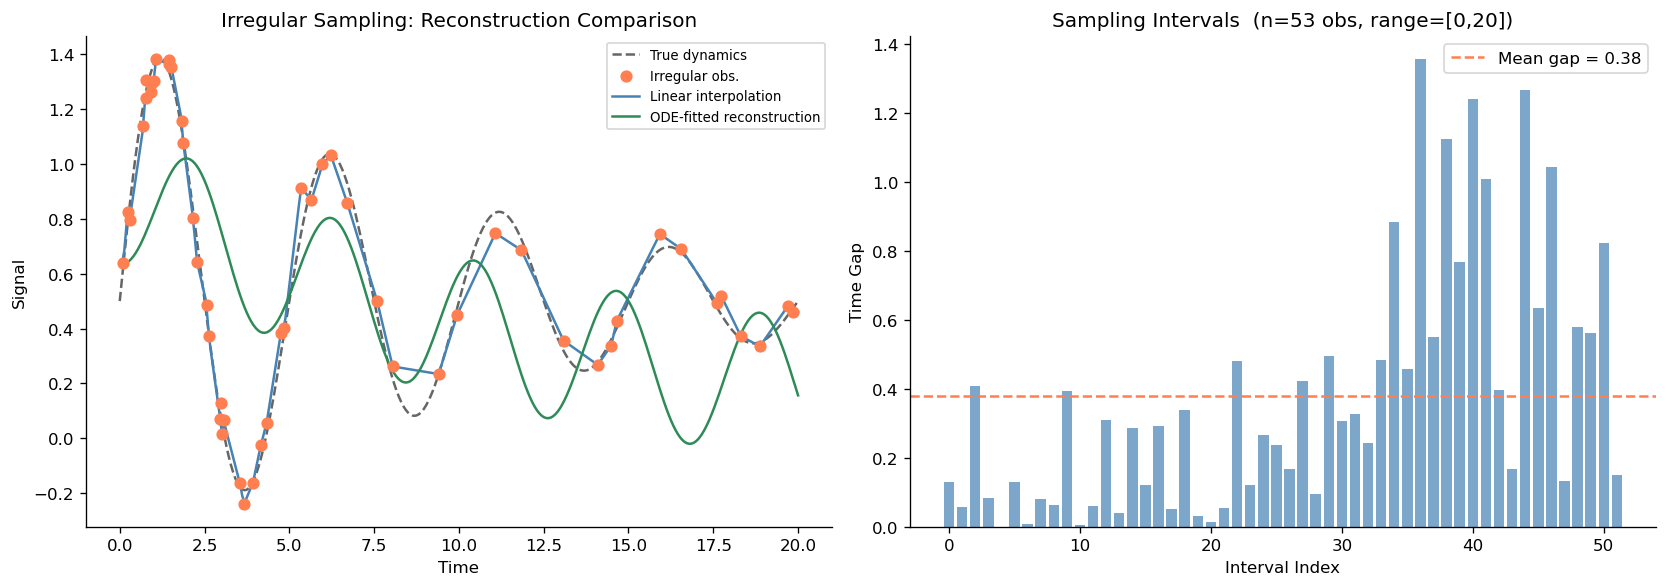

In [5]:
# Simulate irregularly sampled physiological signal
np.random.seed(SEED)

def true_dynamics(t):
    return np.exp(-0.1 * t) * np.sin(2 * np.pi * t / 5) + 0.5

# Irregular sampling: dense early, sparse late
t_irreg = np.sort(np.concatenate([
    np.random.uniform(0,  5, 30),
    np.random.uniform(5, 15, 15),
    np.random.uniform(15,20,  8),
]))
y_irreg = true_dynamics(t_irreg) + np.random.normal(0, 0.05, len(t_irreg))

# Dense evaluation grid
t_reg = np.linspace(0, 20, 300)
y_true_reg = true_dynamics(t_reg)

# Method 1: Linear interpolation (standard naive approach)
y_interp = np.interp(t_reg, t_irreg, y_irreg)

# Method 2: Parametric ODE fit (proxy for Neural ODE)
from scipy.integrate import odeint
from scipy.optimize import curve_fit

def ode_rhs(y, t, a, omega, b):
    return -a * y + b * np.sin(omega * t)

try:
    popt, _ = curve_fit(
        lambda t, a, om, b: odeint(ode_rhs, y_irreg[0], t, args=(a,om,b)).flatten(),
        t_irreg, y_irreg, p0=[0.1, 1.3, 1.0], maxfev=3000
    )
    y_ode = odeint(ode_rhs, y_irreg[0], t_reg, args=tuple(popt)).flatten()
    print(f'Fitted ODE: a={popt[0]:.3f}, omega={popt[1]:.3f}, b={popt[2]:.3f}')
except Exception as e:
    print(f'ODE fit failed ({e}); using interpolation as fallback')
    y_ode = y_interp

# Compare RMSE
rmse_interp = np.sqrt(mean_squared_error(y_true_reg, y_interp))
rmse_ode    = np.sqrt(mean_squared_error(y_true_reg, y_ode))
print(f'Linear interpolation RMSE: {rmse_interp:.5f}')
print(f'ODE-fitted model RMSE:     {rmse_ode:.5f}')
print(f'ODE improvement: {(rmse_interp-rmse_ode)/rmse_interp*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(t_reg, y_true_reg, 'k--', lw=1.5, label='True dynamics', alpha=0.6)
axes[0].scatter(t_irreg, y_irreg, s=40, c='coral', zorder=5, label='Irregular obs.')
axes[0].plot(t_reg, y_interp, 'steelblue', lw=1.5, label='Linear interpolation')
axes[0].plot(t_reg, y_ode, 'seagreen', lw=1.5, label='ODE-fitted reconstruction')
axes[0].set_xlabel('Time'); axes[0].set_ylabel('Signal')
axes[0].set_title('Irregular Sampling: Reconstruction Comparison'); axes[0].legend(fontsize=8)

gaps = np.diff(t_irreg)
axes[1].bar(range(len(gaps)), gaps, color='steelblue', alpha=0.7)
axes[1].axhline(np.mean(gaps), color='coral', linestyle='--',
                label=f'Mean gap = {np.mean(gaps):.2f}')
axes[1].set_xlabel('Interval Index'); axes[1].set_ylabel('Time Gap')
axes[1].set_title(f'Sampling Intervals  (n={len(t_irreg)} obs, range=[0,20])')
axes[1].legend()
plt.tight_layout(); plt.show()


### Interpretation

- Linear interpolation creates artificially smooth trajectories between observations and is unreliable in large gaps where the true dynamics may be non-monotone.
- The ODE-based approach fits a continuous dynamical model, providing principled reconstruction at any time point including between and beyond observations.
- A full Neural ODE replaces the parametric ODE with $f_\theta$ (a neural network), providing universal approximation of arbitrary dynamics without specifying functional form.


---
# 4. Walk-Forward Validation and Selection Guide

> **Never use random cross-validation for time series.** Test folds must always be strictly after training folds to prevent temporal data leakage.

## Walk-Forward Validation

```
Time: ──────────────────────────────────────────────>
      |-- Train --|Test|                              Step 1
          |-- Train  --|Test|                         Step 2
               |-- Train   --|Test|                   Step 3
```

## Algorithm Selection for Time-Series

| Scenario | Recommended | Reason |
|---|---|---|
| Stationary univariate, short horizon | ARIMA | Principled; interpretable |
| Trend + seasonality + holidays | Prophet | Handles all components natively |
| Multiple correlated series | VAR / LightGBM with lag features | Joint modeling |
| Irregularly sampled observations | Latent ODE | Handles arbitrary sampling times |
| Non-linear patterns, long sequences | LSTM / Transformer | Deep sequential modeling |
| Limited data | ARIMA / Prophet | Few parameters; regularized priors |
| Automated at scale | Prophet / Auto-ARIMA | Robust defaults; minimal tuning |


Walk-Forward ARIMA(1,1,1): RMSE=13.00  MAE=10.35


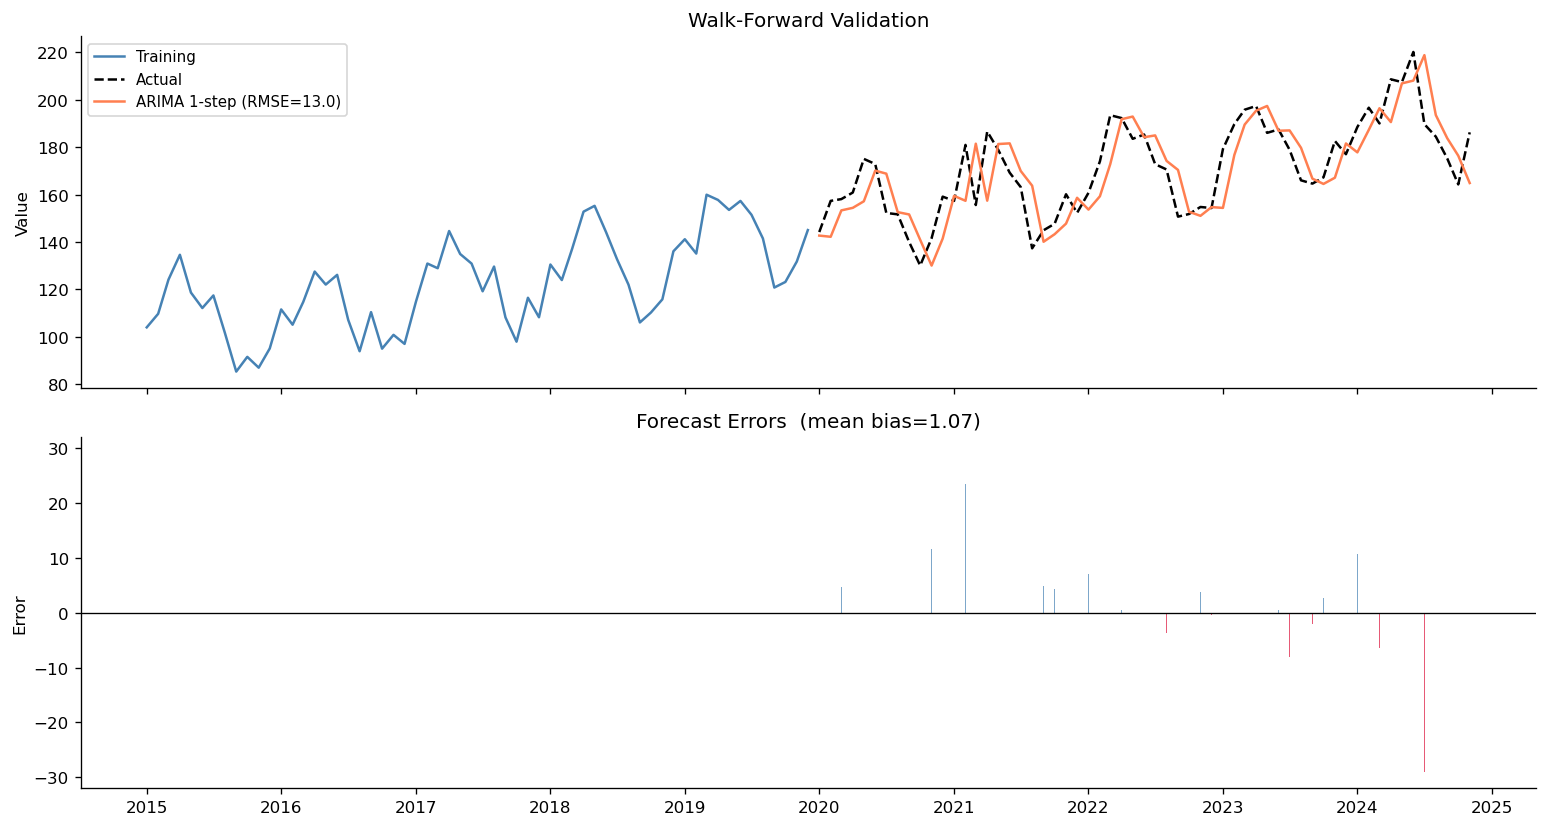

In [6]:
# Walk-forward validation: ARIMA(1,1,1) rolling 1-step-ahead forecast
if STATSMODELS_OK:
    np.random.seed(SEED)
    n_ts = 120
    t_arr = np.arange(n_ts)
    y_ts  = 100 + 0.8*t_arr + 20*np.sin(2*np.pi*t_arr/12) + np.random.normal(0, 8, n_ts)
    ts_wf = pd.Series(y_ts, index=pd.date_range('2015-01', periods=n_ts, freq='MS'))

    actuals, predictions, origins = [], [], []
    for start in range(60, n_ts - 1):
        tr_wf = ts_wf.iloc[:start]
        try:
            m_wf   = ARIMA(tr_wf, order=(1,1,1)).fit()
            pred   = m_wf.forecast(steps=1).iloc[0]
        except Exception:
            pred = tr_wf.iloc[-1]
        actuals.append(ts_wf.iloc[start])
        predictions.append(pred)
        origins.append(ts_wf.index[start])

    actuals     = np.array(actuals)
    predictions = np.array(predictions)
    rmse_wf = np.sqrt(mean_squared_error(actuals, predictions))
    mae_wf  = mean_absolute_error(actuals, predictions)
    print(f'Walk-Forward ARIMA(1,1,1): RMSE={rmse_wf:.2f}  MAE={mae_wf:.2f}')

    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    axes[0].plot(ts_wf.index[:60], ts_wf.values[:60], color='steelblue', lw=1.5, label='Training')
    axes[0].plot(origins, actuals,     color='black',  lw=1.5, linestyle='--', label='Actual')
    axes[0].plot(origins, predictions, color='coral',  lw=1.5,
                 label=f'ARIMA 1-step (RMSE={rmse_wf:.1f})')
    axes[0].set_title('Walk-Forward Validation'); axes[0].set_ylabel('Value')
    axes[0].legend(fontsize=9)

    errors = actuals - predictions
    axes[1].bar(origins, errors,
                color=['crimson' if e < 0 else 'steelblue' for e in errors], alpha=0.7)
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_title(f'Forecast Errors  (mean bias={errors.mean():.2f})')
    axes[1].set_ylabel('Error')
    plt.tight_layout(); plt.show()
else:
    print('Install statsmodels for this demo:  pip install statsmodels')
